# **LSTM AUTOENCODER FOR DETECTING ANOMALY IN A GAS SENSOR DATASET**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q torch pandas matplotlib

In [ ]:
import os
os.makedirs("models", exist_ok=True)

In [ ]:
import numpy as np
import random
import torch
import shap
import matplotlib.pyplot as plt

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# **LOADING OF DATASET**

In [ ]:
import os

base = "/content/drive/MyDrive/thermal_data"

for root, dirs, files in os.walk(base):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

/content/drive/MyDrive/thermal_data/Gas_Sensors_Measurements/Gas_Sensors_Measurements.csv


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/thermal_data/Gas_Sensors_Measurements/Gas_Sensors_Measurements.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

   Serial Number  MQ2  MQ3  MQ5  MQ6  MQ7  MQ8  MQ135    Gas  \
0              0  555  515  377  338  666  451    416  NoGas   
1              1  555  516  377  339  666  451    416  NoGas   
2              2  556  517  376  337  666  451    416  NoGas   
3              3  556  516  376  336  665  451    416  NoGas   
4              4  556  516  376  337  665  451    416  NoGas   

  Corresponding Image Name  
0                  0_NoGas  
1                  1_NoGas  
2                  2_NoGas  
3                  3_NoGas  
4                  4_NoGas  
Index(['Serial Number', 'MQ2', 'MQ3', 'MQ5', 'MQ6', 'MQ7', 'MQ8', 'MQ135',
       'Gas', 'Corresponding Image Name'],
      dtype='object')


In [ ]:
sensor_features = ["MQ2", "MQ3", "MQ5", "MQ6", "MQ7", "MQ8", "MQ135"]

# Keep only NoGas samples
normal_df = df[df["Gas"] == "NoGas"][sensor_features].reset_index(drop=True)


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(normal_df.values)

In [ ]:
def create_sequences(data, seq_len=20):
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i + seq_len])
    return np.array(sequences)

SEQ_LEN = 20
X = create_sequences(scaled_data, SEQ_LEN)

print(X.shape)  # (N, 20, 7)


(1580, 20, 7)


In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_tensor = torch.tensor(X, dtype=torch.float32)

dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# **BUILDING AND TRAINING OF MODEL**

In [ ]:
import torch.nn as nn

class LSTMAutoencoder(nn.Module):
    def __init__(self, num_features, hidden_size=32, seq_len=20):
        super().__init__()
        self.seq_len = seq_len

        self.encoder = nn.LSTM(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.decoder = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.output_layer = nn.Linear(hidden_size, num_features)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)

        repeated = hidden.repeat(self.seq_len, 1, 1).permute(1, 0, 2)
        decoded, _ = self.decoder(repeated)

        return self.output_layer(decoded)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = LSTMAutoencoder(
    num_features=len(sensor_features),
    hidden_size=32,
    seq_len=SEQ_LEN
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
EPOCHS = 40

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for (batch,) in loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        recon = model(batch)
        loss = criterion(recon, batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(loader):.6f}")


Epoch 1/40 | Loss: 0.281957
Epoch 2/40 | Loss: 0.050043
Epoch 3/40 | Loss: 0.037154
Epoch 4/40 | Loss: 0.031166
Epoch 5/40 | Loss: 0.024173
Epoch 6/40 | Loss: 0.020578
Epoch 7/40 | Loss: 0.017996
Epoch 8/40 | Loss: 0.014978
Epoch 9/40 | Loss: 0.011417
Epoch 10/40 | Loss: 0.009792
Epoch 11/40 | Loss: 0.009149
Epoch 12/40 | Loss: 0.008657
Epoch 13/40 | Loss: 0.008350
Epoch 14/40 | Loss: 0.008073
Epoch 15/40 | Loss: 0.007840
Epoch 16/40 | Loss: 0.007606
Epoch 17/40 | Loss: 0.007367
Epoch 18/40 | Loss: 0.007178
Epoch 19/40 | Loss: 0.006762
Epoch 20/40 | Loss: 0.006280
Epoch 21/40 | Loss: 0.005818
Epoch 22/40 | Loss: 0.005336
Epoch 23/40 | Loss: 0.004952
Epoch 24/40 | Loss: 0.004432
Epoch 25/40 | Loss: 0.004233
Epoch 26/40 | Loss: 0.003862
Epoch 27/40 | Loss: 0.003697
Epoch 28/40 | Loss: 0.003592
Epoch 29/40 | Loss: 0.003497
Epoch 30/40 | Loss: 0.003427
Epoch 31/40 | Loss: 0.003344
Epoch 32/40 | Loss: 0.003201
Epoch 33/40 | Loss: 0.003135
Epoch 34/40 | Loss: 0.003074
Epoch 35/40 | Loss: 0.0

In [ ]:
def reconstruction_error(x, x_hat):
    return torch.mean((x - x_hat) ** 2, dim=(1, 2))

In [ ]:
model.eval()

# DO NOT refit scaler
# scaler should already be fitted during training

# Transform full dataset using existing scaler
all_scaled = scaler.transform(df[sensor_features])

# Create sequences
all_seq = create_sequences(all_scaled, SEQ_LEN)

# Convert to tensor
all_tensor = torch.tensor(all_seq, dtype=torch.float32).to(device)

with torch.no_grad():
    recon = model(all_tensor)
    scores = reconstruction_error(all_tensor, recon).cpu().numpy()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


# **METRICES AND RESULTS**

In [ ]:
threshold = np.percentile(scores[df["Gas"].iloc[SEQ_LEN:] == "NoGas"], 95)

print("Anomaly threshold:", threshold)

is_anomaly = scores > threshold

Anomaly threshold: 0.00700815


In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np

# Align labels with sequences (we lost first SEQ_LEN rows)
true_labels = df["Gas"].iloc[SEQ_LEN:].values

# Binary labels: 0 = normal, 1 = anomaly
y_true = np.array([0 if g == "NoGas" else 1 for g in true_labels])

# Separate reconstruction errors
errors_normal = scores[y_true == 0]
errors_anomaly = scores[y_true == 1]

# ---- Mean Reconstruction Loss ----
mean_normal = np.mean(errors_normal)
mean_anomaly = np.mean(errors_anomaly)

print("Mean reconstruction loss (normal):", mean_normal)
print("Mean reconstruction loss (anomaly):", mean_anomaly)

# ---- ROC-AUC ----
roc_auc = roc_auc_score(y_true, scores)
print("ROC-AUC:", roc_auc)

# ---- Threshold (95th percentile of normal) ----
threshold = np.percentile(errors_normal, 95)
print("Anomaly threshold:", threshold)

# ---- Predictions ----
y_pred = (scores > threshold).astype(int)

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()

FPR = FP / (FP + TN)
FNR = FN / (FN + TP)

print("Confusion Matrix:\n", cm)
print("False Positive Rate:", FPR)
print("False Negative Rate:", FNR)

Mean reconstruction loss (normal): 0.0027229267
Mean reconstruction loss (anomaly): 2.0816588
ROC-AUC: 0.9634733649789029
Anomaly threshold: 0.00700815
Confusion Matrix:
 [[1501   79]
 [ 582 4218]]
False Positive Rate: 0.05
False Negative Rate: 0.12125


In [ ]:
MODEL_PATH = "models/lstm_autoencoder_weights.pth"

torch.save(model.state_dict(), MODEL_PATH)

In [ ]:
import json

model_config = {
    "num_features": 7,
    "hidden_size": 32,
    "seq_len": SEQ_LEN
}

with open("models/model_config.json", "w") as f:
    json.dump(model_config, f)

In [ ]:
import joblib

SCALER_PATH = "minmax_scaler.save"
joblib.dump(scaler, SCALER_PATH)

['minmax_scaler.save']

In [ ]:
import numpy as np

np.save("models/anomaly_threshold.npy", threshold)

In [ ]:
import json
import torch

# Load config
with open("models/model_config.json") as f:
    config = json.load(f)

# Rebuild model
model = LSTMAutoencoder(
    num_features=config["num_features"],
    hidden_size=config["hidden_size"],
    seq_len=config["seq_len"]
)

# Load weights
model.load_state_dict(torch.load("models/lstm_autoencoder_weights.pth", map_location="cpu"))
model.eval()

LSTMAutoencoder(
  (encoder): LSTM(7, 32, batch_first=True)
  (decoder): LSTM(32, 32, batch_first=True)
  (output_layer): Linear(in_features=32, out_features=7, bias=True)
)

In [ ]:
model.eval()

all_scaled = scaler.transform(df[sensor_features])
all_seq = create_sequences(all_scaled, SEQ_LEN)

import torch
all_tensor = torch.tensor(all_seq, dtype=torch.float32).to(device)

with torch.no_grad():
    recon = model(all_tensor)
    scores = reconstruction_error(all_tensor, recon).cpu().numpy()

print(scores[:10])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


[0.00241573 0.00239904 0.00234717 0.00227333 0.00226755 0.00224648
 0.00223798 0.00214893 0.00214731 0.00210138]


In [ ]:
import numpy as np

true_labels = df["Gas"].iloc[SEQ_LEN:].values
y_true = np.array([0 if g == "NoGas" else 1 for g in true_labels])

labels_df = pd.DataFrame({
    "gas_label": true_labels,
    "binary_label": y_true
})

print(labels_df.head())

threshold = np.percentile(scores[y_true == 0], 95)
print("Threshold:", threshold)

y_pred = (scores > threshold).astype(int)

  gas_label  binary_label
0     NoGas             0
1     NoGas             0
2     NoGas             0
3     NoGas             0
4     NoGas             0
Threshold: 0.00700815


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

roc_auc = roc_auc_score(y_true, scores)
cm = confusion_matrix(y_true, y_pred)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

auto_summary_df = pd.DataFrame([
    {"Metric": "Threshold", "Value": float(threshold)},
    {"Metric": "ROC-AUC", "Value": float(roc_auc)},
    {"Metric": "Accuracy", "Value": float(acc)},
    {"Metric": "Precision", "Value": float(prec)},
    {"Metric": "Recall", "Value": float(rec)},
    {"Metric": "F1-score", "Value": float(f1)},
    {"Metric": "Specificity", "Value": float(specificity)},
    {"Metric": "False Positive Rate", "Value": float(fpr)},
    {"Metric": "False Negative Rate", "Value": float(fnr)},
    {"Metric": "Mean Normal Score", "Value": float(scores[y_true == 0].mean())},
    {"Metric": "Mean Anomaly Score", "Value": float(scores[y_true == 1].mean())},
])

print(auto_summary_df)

                 Metric     Value
0             Threshold  0.007008
1               ROC-AUC  0.963473
2              Accuracy  0.896395
3             Precision  0.981615
4                Recall  0.878750
5              F1-score  0.927339
6           Specificity  0.950000
7   False Positive Rate  0.050000
8   False Negative Rate  0.121250
9     Mean Normal Score  0.002723
10   Mean Anomaly Score  2.081659


In [ ]:
auto_cm_df = pd.DataFrame(
    cm,
    index=["True_Normal", "True_Anomaly"],
    columns=["Pred_Normal", "Pred_Anomaly"]
)

print(auto_cm_df)

              Pred_Normal  Pred_Anomaly
True_Normal          1501            79
True_Anomaly          582          4218


In [ ]:
auto_report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Anomaly"],
    output_dict=True,
    digits=4
)

auto_report_df = pd.DataFrame(auto_report_dict).transpose()
print(auto_report_df)

              precision    recall  f1-score      support
Normal         0.720595  0.950000  0.819547  1580.000000
Anomaly        0.981615  0.878750  0.927339  4800.000000
accuracy       0.896395  0.896395  0.896395     0.896395
macro avg      0.851105  0.914375  0.873443  6380.000000
weighted avg   0.916974  0.896395  0.900644  6380.000000


In [ ]:
auto_scores_df = pd.DataFrame({
    "true_label": y_true,
    "score": scores,
    "predicted_label": y_pred
})

print(auto_scores_df.head(20))

    true_label     score  predicted_label
0            0  0.002416                0
1            0  0.002399                0
2            0  0.002347                0
3            0  0.002273                0
4            0  0.002268                0
5            0  0.002246                0
6            0  0.002238                0
7            0  0.002149                0
8            0  0.002147                0
9            0  0.002101                0
10           0  0.002041                0
11           0  0.001999                0
12           0  0.001949                0
13           0  0.001921                0
14           0  0.001899                0
15           0  0.001870                0
16           0  0.001840                0
17           0  0.001742                0
18           0  0.001725                0
19           0  0.001669                0


In [ ]:
def anomaly_score_fn(x):

    x_reshaped = x.reshape(-1, SEQ_LEN, len(sensor_features))
    x_tensor = torch.tensor(x_reshaped, dtype=torch.float32).to(device)

    model.eval()
    with torch.no_grad():
        recon = model(x_tensor)
        error = torch.mean((x_tensor - recon) ** 2, dim=(1, 2))

    return error.cpu().numpy()

X_flat = all_seq.reshape(all_seq.shape[0], -1)
print(f"X_flat prepared with shape: {X_flat.shape}")

X_flat prepared with shape: (6380, 140)


In [ ]:
# USE YOUR EXISTING FUNCTION OUTPUT
errors = anomaly_score_fn(X_flat)

recon_df = pd.DataFrame({
    "Sample_ID": np.arange(len(errors)),
    "Reconstruction_Error": errors
})

recon_df.head()

,Sample_ID,Reconstruction_Error
0,0,0.002416
1,1,0.002399
2,2,0.002347
3,3,0.002273
4,4,0.002268


In [ ]:
threshold_grid = np.linspace(scores.min(), scores.max(), 20)

rows = []
for thr in threshold_grid:
    pred = (scores > thr).astype(int)
    cm_thr = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm_thr.ravel()

    rows.append({
        "threshold": float(thr),
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1_score": f1_score(y_true, pred, zero_division=0),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
    })

threshold_sensitivity_df = pd.DataFrame(rows)
print(threshold_sensitivity_df)

    threshold  accuracy  precision    recall  f1_score       fpr       fnr
0    0.000285  0.752508   0.752469  1.000000  0.858753  0.999367  0.000000
1    0.311359  0.749060   1.000000  0.666458  0.799850  0.000000  0.333542
2    0.622432  0.748903   1.000000  0.666250  0.799700  0.000000  0.333750
3    0.933506  0.745298   1.000000  0.661458  0.796238  0.000000  0.338542
4    1.244579  0.723511   1.000000  0.632500  0.774885  0.000000  0.367500
5    1.555653  0.676646   1.000000  0.570208  0.726284  0.000000  0.429792
6    1.866727  0.634169   1.000000  0.513750  0.678778  0.000000  0.486250
7    2.177800  0.550157   1.000000  0.402083  0.573551  0.000000  0.597917
8    2.488873  0.500627   1.000000  0.336250  0.503274  0.000000  0.663750
9    2.799947  0.460345   1.000000  0.282708  0.440799  0.000000  0.717292
10   3.111021  0.436207   1.000000  0.250625  0.400800  0.000000  0.749375
11   3.422094  0.427273   1.000000  0.238750  0.385469  0.000000  0.761250
12   3.733168  0.415517  

In [ ]:
errors = anomaly_score_fn(X_flat)

recon_df = pd.DataFrame({
    "Sample_ID": np.arange(len(errors)),
    "Reconstruction_Error": errors
})

recon_df.head()

,Sample_ID,Reconstruction_Error
0,0,0.002416
1,1,0.002399
2,2,0.002347
3,3,0.002273
4,4,0.002268


In [ ]:
threshold = np.percentile(errors, 95)  # or 90 / 99

recon_df["Anomaly"] = (errors > threshold).astype(int)

recon_df.head()

,Sample_ID,Reconstruction_Error,Anomaly
0,0,0.002416,0
1,1,0.002399,0
2,2,0.002347,0
3,3,0.002273,0
4,4,0.002268,0


In [ ]:
threshold = np.percentile(errors, 95)

recon_df["Threshold"] = threshold
recon_df["Anomaly"] = (errors > threshold).astype(int)

recon_df.head()

,Sample_ID,Reconstruction_Error,Anomaly,Threshold
0,0,0.002416,0,5.491802
1,1,0.002399,0,5.491802
2,2,0.002347,0,5.491802
3,3,0.002273,0,5.491802
4,4,0.002268,0,5.491802


In [ ]:
summary_df = pd.DataFrame({
    "Metric": [
        "Mean Error",
        "Max Error",
        "Min Error",
        "Threshold (95%)",
        "Num Anomalies"
    ],
    "Value": [
        errors.mean(),
        errors.max(),
        errors.min(),
        threshold,
        (errors > threshold).sum()
    ]
})

summary_df

,Metric,Value
0,Mean Error,1.566813
1,Max Error,5.910682
2,Min Error,0.000285
3,Threshold (95%),5.491802
4,Num Anomalies,319.000000


In [ ]:
import shap
import numpy as np
import pandas as pd

background = X_flat[:50]
X_sample = X_flat[:20]

explainer = shap.KernelExplainer(anomaly_score_fn, background)

print("Calculating SHAP values (this may take a minute)...")
shap_values = explainer.shap_values(X_sample)

shap_array = np.array(shap_values)

if len(shap_array.shape) == 3:

    shap_array_flat = shap_array.reshape(shap_array.shape[0], -1)
else:
    shap_array_flat = shap_array

shap_df = pd.DataFrame(
    shap_array_flat,
    columns=[f"Feature_{i}" for i in range(shap_array_flat.shape[1])]
)

display(shap_df.head())

Calculating SHAP values (this may take a minute)...


  0%|          | 0/20 [00:00<?, ?it/s]

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,...,Feature_130,Feature_131,Feature_132,Feature_133,Feature_134,Feature_135,Feature_136,Feature_137,Feature_138,Feature_139
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.000293,0.0,0.0,0.0,0.0,-0.000215,0.0,-0.000288,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.000262,0.0,0.0,0.0,0.0,-0.000212,0.0,-0.000287,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.000274,0.0,0.0,0.0,0.0,-0.000189,0.0,-0.000277,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.000293,0.0,0.0,0.0,0.0,-0.000243,0.0,-0.000348,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-0.000279,0.0,0.0,0.0,0.0,-0.000208,0.0,-0.000325,0.0


In [ ]:
num_sensors = len(sensor_features)

# Reshape SHAP values back to (samples, sequence_length, features)
shap_reshaped = shap_array.reshape(-1, SEQ_LEN, num_sensors)

importance_sensor = np.abs(shap_reshaped).mean(axis=(0, 1))

sensor_df = pd.DataFrame({
    "Sensor": sensor_features,
    "Importance": importance_sensor
}).sort_values(by="Importance", ascending=False)

display(sensor_df)

,Sensor,Importance
5,MQ8,0.000109
3,MQ6,0.000024
0,MQ2,0.000000
2,MQ5,0.000000
1,MQ3,0.000000
4,MQ7,0.000000
6,MQ135,0.000000


# **VISUALIZATION AND PLOTS**

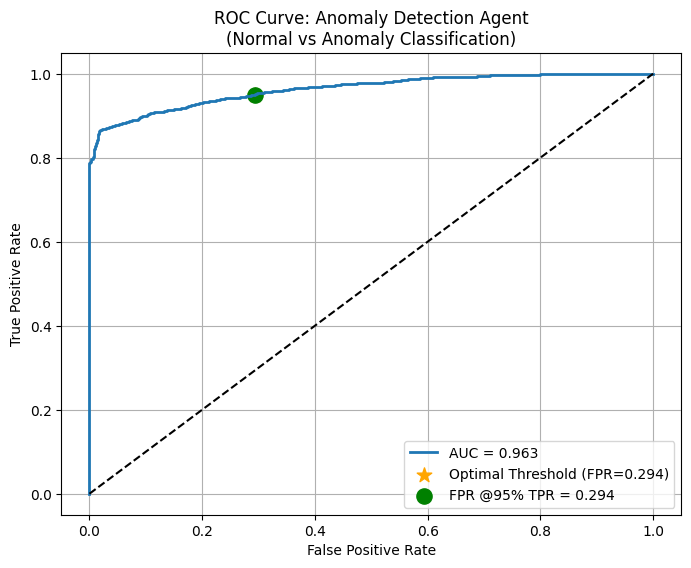

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_curve, tpr_curve, thresholds = roc_curve(y_true, scores)

# Find threshold at ~95% TPR
target_tpr = 0.95
idx = np.argmax(tpr_curve >= target_tpr)

opt_fpr = fpr_curve[idx]
opt_tpr = tpr_curve[idx]
opt_thresh = thresholds[idx]

plt.figure(figsize=(8,6))

# ROC curve
plt.plot(fpr_curve, tpr_curve, linewidth=2, label=f"AUC = {roc_auc:.3f}")

# Random classifier
plt.plot([0,1],[0,1],'k--')

# Optimal point
plt.scatter(opt_fpr, opt_tpr, color="orange", s=120, marker="*", label=f"Optimal Threshold (FPR={opt_fpr:.3f})")

# FPR @ 95% TPR
plt.scatter(opt_fpr, opt_tpr, color="green", s=120, label=f"FPR @95% TPR = {opt_fpr:.3f}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Anomaly Detection Agent\n(Normal vs Anomaly Classification)")
plt.legend()
plt.grid(True)

plt.show()

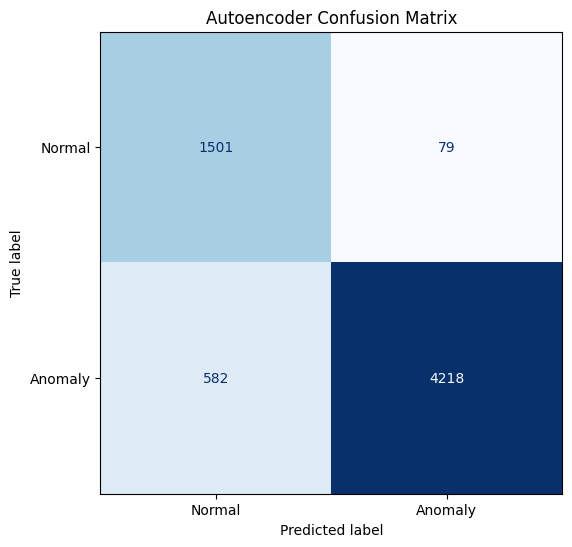

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Autoencoder Confusion Matrix")
plt.show()

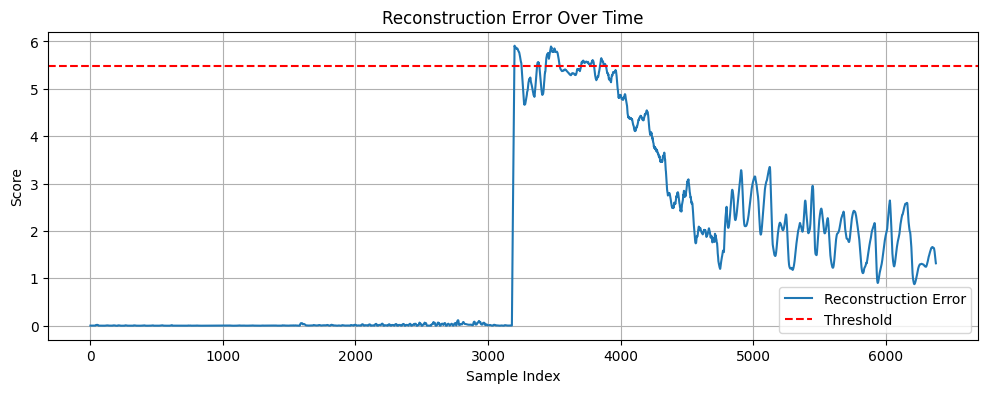

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(scores, label="Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.xlabel("Sample Index")
plt.ylabel("Score")
plt.title("Reconstruction Error Over Time")
plt.legend()
plt.grid(True)
plt.show()

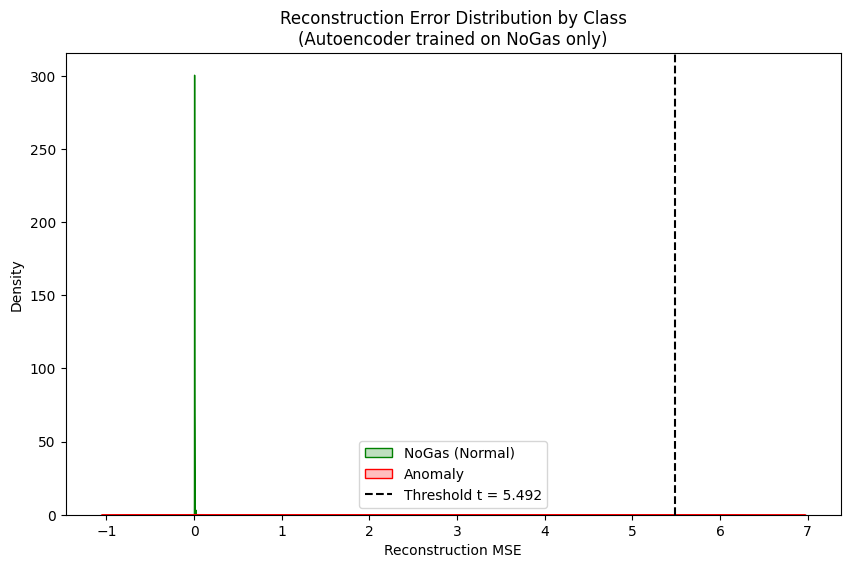

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.kdeplot(scores[y_true==0], label="NoGas (Normal)", color="green", fill=True)
sns.kdeplot(scores[y_true==1], label="Anomaly", color="red", fill=True)

plt.axvline(threshold, color="black", linestyle="--", label=f"Threshold t = {threshold:.3f}")

plt.xlabel("Reconstruction MSE")
plt.ylabel("Density")
plt.title("Reconstruction Error Distribution by Class\n(Autoencoder trained on NoGas only)")
plt.legend()
plt.show()

Starting SHAP...


  0%|          | 0/40 [00:00<?, ?it/s]

SHAP DONE
  Sensor    Importance
0    MQ2  0.000000e+00
2    MQ5  4.755270e-09
3    MQ6  8.449757e-08
5    MQ8  1.152288e-07
6  MQ135  3.741232e-06
1    MQ3  6.661344e-06
4    MQ7  1.021193e-05


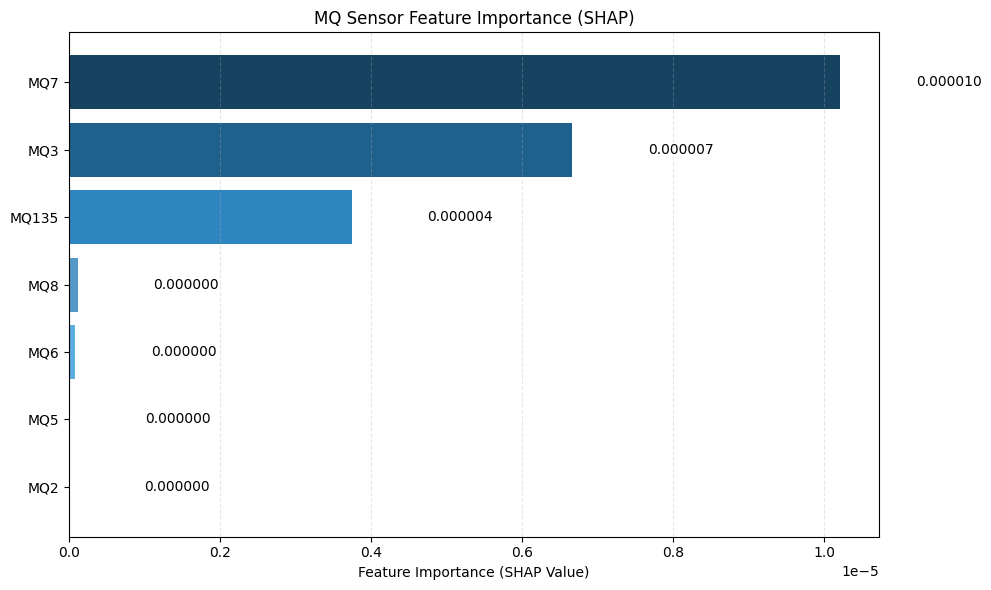

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import shap
import numpy as np
import pandas as pd
import torch

# -------------------------
# ANOMALY FUNCTION
# -------------------------
def anomaly_score_fn(x):
    x = x.reshape(-1, SEQ_LEN, len(sensor_features))
    x_tensor = torch.tensor(x, dtype=torch.float32).to(device)

    with torch.no_grad():
        recon = model(x_tensor)
        error = torch.mean((x_tensor - recon) ** 2, dim=(1, 2))

    return error.cpu().numpy()


# -------------------------
# DATA PREP
# -------------------------
X_seq = all_seq
X_flat = X_seq.reshape(X_seq.shape[0], -1)
X_reduced = X_seq.mean(axis=1)  # (N, features only)

X_sample = X_flat[:40]
background = X_flat[:20]

# -------------------------
# SHAP
# -------------------------
explainer = shap.KernelExplainer(anomaly_score_fn, background)

print("Starting SHAP...")
shap_values = explainer.shap_values(X_sample)
print("SHAP DONE")

# reshape
shap_values = shap_values.reshape(-1, SEQ_LEN, len(sensor_features))

mean_importance = np.abs(shap_values).mean(axis=(0,1))

sensor_names = ["MQ2","MQ3","MQ5","MQ6","MQ7","MQ8","MQ135"]

importance_df = pd.DataFrame({
    "Sensor": sensor_names,
    "Importance": mean_importance
}).sort_values(by="Importance", ascending=True)

print(importance_df)

# -------------------------
# PLOT (FORCED RENDER)
# -------------------------
plt.figure(figsize=(10,6))

colors = ["#7FB3D5","#6FA8DC","#5DADE2","#5499C7","#2E86C1","#1F618D","#154360"]

bars = plt.barh(
    importance_df["Sensor"],
    importance_df["Importance"],
    color=colors
)

# annotations
for i, v in enumerate(importance_df["Importance"]):
    plt.text(v + 0.000001, i, f"{v:.6f}", va='center')

plt.xlabel("Feature Importance (SHAP Value)")
plt.title("MQ Sensor Feature Importance (SHAP)")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

# 🔥 CRITICAL LINE
plt.show(block=True)
plt.pause(0.1)

In [ ]:
gas_labels = {
    "MQ2": "Combustible Gas (LPG, Smoke)",
    "MQ3": "Alcohol, Ethanol",
    "MQ5": "Natural Gas, LPG",
    "MQ6": "LPG, Butane",
    "MQ7": "Carbon Monoxide",
    "MQ8": "Hydrogen",
    "MQ135": "Air Quality (NH3, CO2)"
}

importance_df["Gas Type"] = importance_df["Sensor"].map(gas_labels)

print(importance_df)

  Sensor    Importance                      Gas Type
0    MQ2  0.000000e+00  Combustible Gas (LPG, Smoke)
2    MQ5  4.755270e-09              Natural Gas, LPG
3    MQ6  8.449757e-08                   LPG, Butane
5    MQ8  1.152288e-07                      Hydrogen
6  MQ135  3.741232e-06        Air Quality (NH3, CO2)
1    MQ3  6.661344e-06              Alcohol, Ethanol
4    MQ7  1.021193e-05               Carbon Monoxide


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


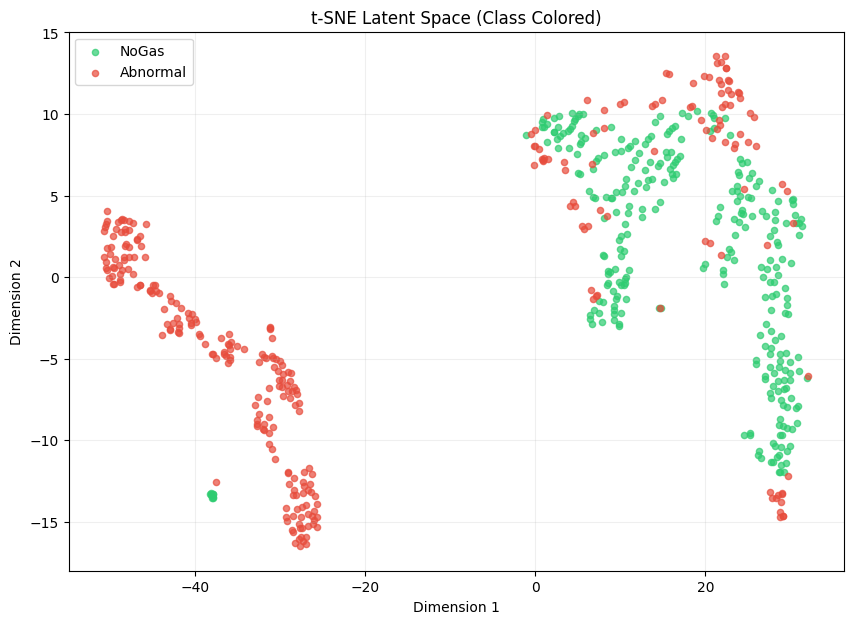

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import torch

model.eval()

with torch.no_grad():
    X_tensor = torch.tensor(all_seq, dtype=torch.float32).to(device)

    # reconstruction
    recon = model(X_tensor)

    # ✅ manual latent extraction
    latent, _ = model.encoder(X_tensor)

    # collapse time dimension
    latent = latent.mean(dim=1)

    latent = latent.cpu().numpy()

# -------------------
# PCA
# -------------------
pca = PCA(n_components=10)
latent_pca = pca.fit_transform(latent)

# -------------------
# BALANCE
# -------------------
def balance_classes(latent, labels, n_per_class=300):
    idx_all = []

    for cls in np.unique(labels):
        idx = np.where(labels == cls)[0]

        replace = len(idx) < n_per_class
        idx_sample = np.random.choice(idx, n_per_class, replace=replace)

        idx_all.append(idx_sample)

    idx_all = np.concatenate(idx_all)
    return latent[idx_all], labels[idx_all]

latent_bal, labels_bal = balance_classes(latent_pca, y_true, 300)

# -------------------
# TSNE
# -------------------
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=100,
    n_iter=2000,
    init='pca',
    random_state=42
)

latent_2d = tsne.fit_transform(latent_bal)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

# 🔥 Define colors (adjust based on your labels)
colors = {
    0: "#2ECC71",   # NoGas (green)
    1: "#E74C3C",   # Smoke (red)
}

names = {
    0: "NoGas",
    1: "Abnormal",
}


for label in np.unique(labels_bal):
    mask = labels_bal == label

    plt.scatter(
        latent_2d[mask, 0],
        latent_2d[mask, 1],
        c=colors.get(label, "#34495E"),
        label=names.get(label, str(label)),
        s=20,
        alpha=0.7
    )

plt.title("t-SNE Latent Space (Class Colored)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [ ]:
print(np.unique(y_true))

[0 1]


# **SAVING THE MODEL WEIGHTS AND PARAMETERS**

In [ ]:
# Put model in eval mode
model.eval()

example_input = torch.randn(1, SEQ_LEN, 7)

traced_model = torch.jit.trace(model, example_input)

TORCHSCRIPT_PATH = "models/lstm_autoencoder_edge.pt"
traced_model.save(TORCHSCRIPT_PATH)

In [ ]:
import torch

# STEP 1: Define example input
example_input = torch.randn(1, 30, 7)

# STEP 2: Quantize model
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {torch.nn.LSTM, torch.nn.Linear},
    dtype=torch.qint8
)

# STEP 3: Trace and save
traced_model = torch.jit.trace(quantized_model, example_input)

traced_model.save("models/lstm_autoencoder_edge_quantized.pt")

/tmp/ipykernel_1373/682307831.py:7: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(
